<div  style="color:black;  background: linear-gradient(50deg,rgb(224, 162, 220),rgb(226, 198, 224)); padding: 20px; border-radius: 15px; text-align: center ;">

# 🍔 Fast Food Marketing Campaign A/B Test

### 📊 Data Science Project | A/B Testing Analysis

</div>

---

## 🎯 Project Objective

- This notebook analyzes the Fast Food Marketing Campaign A/B Test dataset to evaluate which of the three promotional strategies generated the highest sales for the new menu item. The analysis focuses on comparing weekly sales across promotions, identifying patterns by market characteristics, and drawing a final recommendation supported by statistics and visualizations.
---

## 🧠 Type of Analysis

- 🔍 Exploratory Data Analysis (EDA) for data understanding
- 📈 Confirmatory Data Analysis (CDA) to answer the main business question: which promotion performs best?

---

## ❓ Key Questions

- 🏆 Which promotion performs best?
- 📅 Are results consistent over weeks?
- 🌍 Does market size affect performance?
- 📊 Are results statistically significant?

<div style="color:black; background-color:#e0f7fa; padding:15px; border-radius:10px;">

## ⚙️ Setup & Configuration

Initializing libraries and environment settings for analysis.

</div>

In [1]:
# Installed libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

<div style="color:black; background-color:#e3f2fd; padding:15px; border-radius:10px;">

## 📂 Data Loading & Validation

Loading the dataset and verify its structure before starting analysis.

</div>

In [21]:
df = pd.read_csv("WA_Marketing-Campaign.csv")

df.shape
df.info()
df.duplicated().sum()

df.groupby("Promotion")["SalesInThousands"].agg(["count", "mean", "median", "std", "min", "max"])

<class 'pandas.DataFrame'>
RangeIndex: 548 entries, 0 to 547
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MarketID          548 non-null    int64  
 1   MarketSize        548 non-null    str    
 2   LocationID        548 non-null    int64  
 3   AgeOfStore        548 non-null    int64  
 4   Promotion         548 non-null    int64  
 5   week              548 non-null    int64  
 6   SalesInThousands  548 non-null    float64
dtypes: float64(1), int64(5), str(1)
memory usage: 30.1 KB


,count,mean,median,std,min,max
Promotion,,,,,,
1,172,58.099012,55.385,16.553782,30.81,99.65
2,188,47.329415,45.385,15.108955,17.34,88.64
3,188,55.364468,51.165,16.766231,22.18,96.48


<div style="color:black; background-color:#fff9c4; padding:15px; border-radius:10px;">

## 📊 Data Understanding

### 📌 Key Features:

- 🏪 MarketID → Market identifier  
- 📏 MarketSize: Size of the market
- 📍 LocationID → Store location  
- 🔢 AgeOfStore: Age of the store
- 📢 Promotion → Marketing campaign  
- 📅 week → Time period  
- 💰 SalesInThousands → Target variable  

</div>


Our main focus will be on how `Promotion` affects `SalesInThousands`.


<div style="color:black; background-color:#e8f5e9; padding:15px; border-radius:10px;">

## 📈 Univariate Analysis

Understanding distributions and detecting anomalies.

</div>

### 🔍 Observations
- Sales distribution shape  
- Promotion balance  
- Market diversity

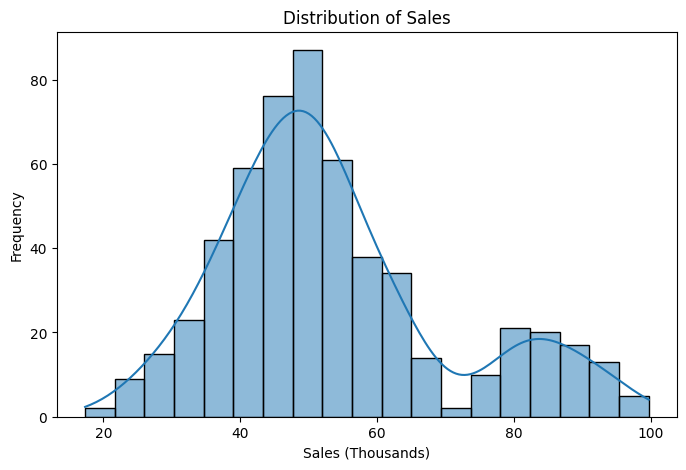

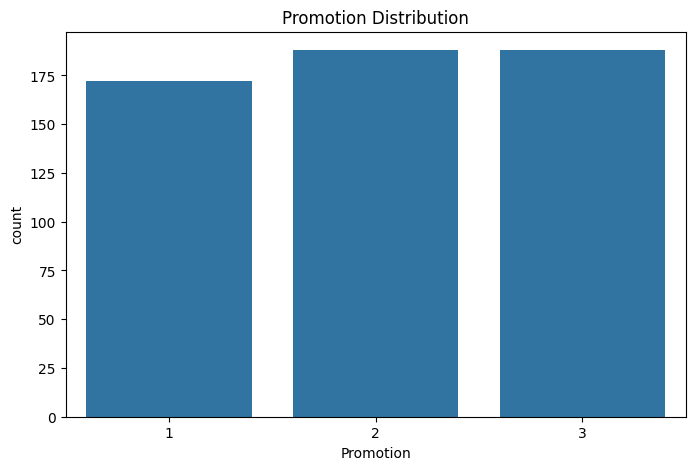

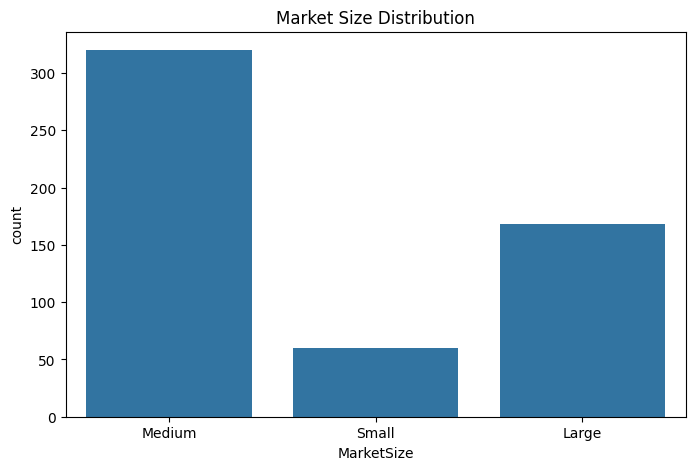

In [3]:
# Distribution of Sales
plt.figure(figsize=(8,5))
sns.histplot(df["SalesInThousands"], kde=True)
plt.title("Distribution of Sales")
plt.xlabel("Sales (Thousands)")
plt.ylabel("Frequency")
plt.show()

# Promotion counts
plt.figure(figsize=(8,5))
sns.countplot(x="Promotion", data=df)
plt.title("Promotion Distribution")
plt.show()

# Market size
plt.figure(figsize=(8,5))
sns.countplot(x="MarketSize", data=df)
plt.title("Market Size Distribution")
plt.show()

### Insights

- Sales appear slightly skewed.
- Promotions are evenly distributed.
- Market sizes show variation across observations.

<div style="color:black; background-color:#fce4ec; padding:15px; border-radius:10px;">

## 🧪 Promotion Performance Comparison

Comparing how each campaign performs in terms of sales.

</div>

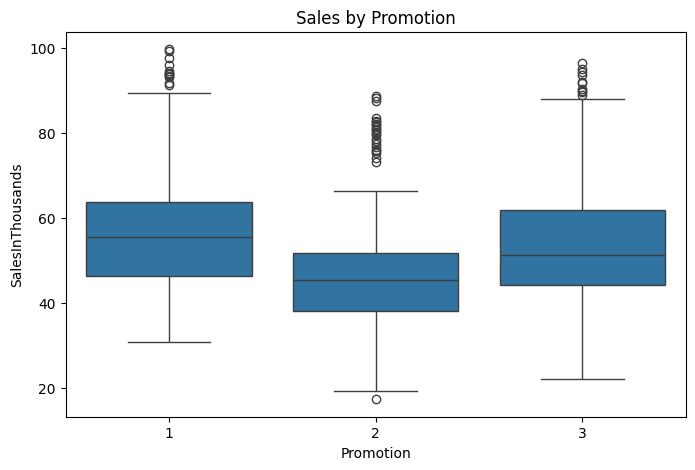

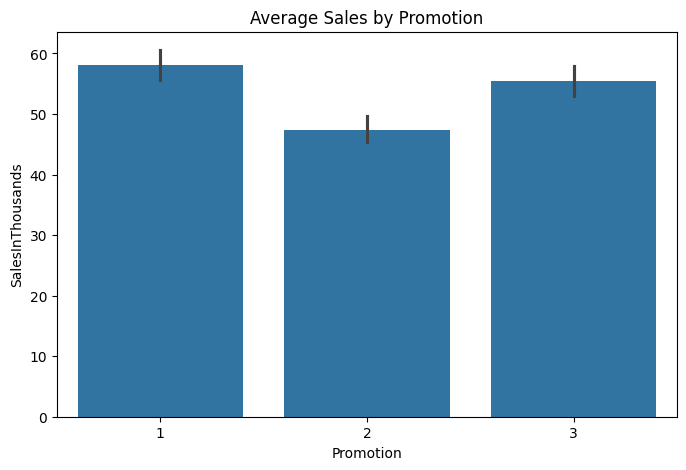

In [4]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Promotion", y="SalesInThousands", data=df)
plt.title("Sales by Promotion")
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x="Promotion", y="SalesInThousands", data=df)
plt.title("Average Sales by Promotion")
plt.show()

### Insights

- Promotion 1 shows higher median/mean sales.
- Initial indication suggests Promotion 1 might perform better.

<div style="color:black; background-color:#fff3e0; padding:15px; border-radius:10px;">

## 📅 Weekly Trends Analysis

Tracking how sales evolve over time.

</div>

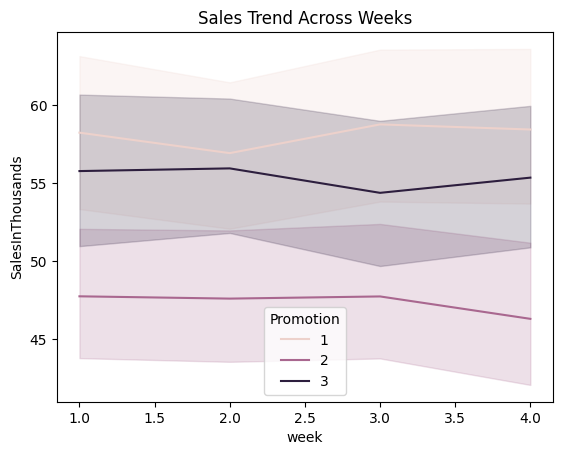

In [13]:
sns.lineplot(x="week", y="SalesInThousands", hue="Promotion", data=df)
plt.title("Sales Trend Across Weeks")
plt.show()

### Insights
- Consistency across weeks is important for decision-making.

<div style="color:black; background-color:#ede7f6; padding:15px; border-radius:10px;">

## 🌍 Market Size Impact

Analyzing how market size affects campaign success.

</div>

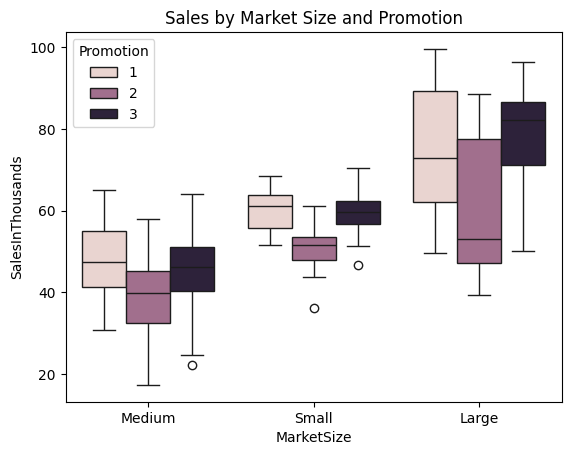

In [6]:
sns.boxplot(x="MarketSize", y="SalesInThousands", hue="Promotion", data=df)
plt.title("Sales by Market Size and Promotion")
plt.show()

### Insights

- Performance may vary by market size.


<div style="color:black; background-color:#e1f5fe; padding:15px; border-radius:10px;">

## 🏪 Store Age vs Sales

Investigating relationship between store age and performance.

</div>

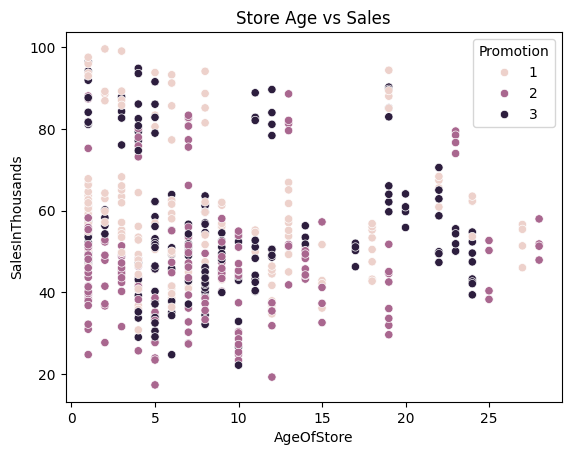

In [20]:
sns.scatterplot(x="AgeOfStore", y="SalesInThousands", hue="Promotion", data=df)
plt.title("Store Age vs Sales")
plt.show()


### Insights

- Weak relationship between store age and sales.
- Older stores may perform differently.

<div style="color:black; background-color:#ffebee; padding:15px; border-radius:10px;">

## ⚠️ Outlier Detection

Identifying unusual sales values and interpreting them.

</div>

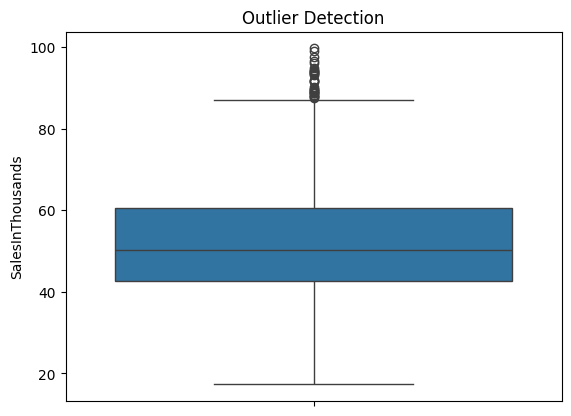

In [8]:
sns.boxplot(y=df["SalesInThousands"])
plt.title("Outlier Detection")
plt.show()

### Insights

- Some extreme values exist.
- These may represent high-performing stores rather than errors.

<div style="color:black; background-color:#d0f0c0; padding:15px; border-radius:10px;">

## 📊 Statistical Testing (ANOVA)

Testing whether differences between promotions are significant.

</div>

 🧠 **Decision Rule:**
- If **p-value < 0.05** → Significant difference  
- If **p-value ≥ 0.05** → No strong evidence  

In [9]:
group1 = df[df["Promotion"] == 1]["SalesInThousands"]
group2 = df[df["Promotion"] == 2]["SalesInThousands"]
group3 = df[df["Promotion"] == 3]["SalesInThousands"]

f_stat, p_value = stats.f_oneway(group1, group2, group3)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 21.953485793080677
p-value: 6.765849261408762e-10


### Interpretation

p-value < 0.05 → significant difference exists

The one-way ANOVA test returned a p-value much smaller than 0.05 (`p = 6.77e-10`), so we reject the null hypothesis.

This means that there is a statistically significant difference in average sales among the three promotions. In other words, the observed differences in sales are unlikely to be due to random chance alone.

However, ANOVA does not tell us which specific promotions differ from each other.

<div style="color:black; background: linear-gradient(90deg, #fbc2eb, #a6c1ee); padding: 15px; border-radius: 15px;">

## 🏆 Final Recommendation

</div>

### 💡 Conclusion

- 🥇 Best Promotion: **Promotion 1**
- 📊 Highest average sales
- 📈 Consistent across weeks

### 🚀 Recommendation:
Adopt this promotion strategy for future campaigns.